# 🌳 Green Space Sub-Metric Analysis
## Pittsburgh's Best Neighborhood: A Tree & Environmental Benefits Perspective

**Author:** Sohan Udumula  
**Team:** Three Rivers Analytics  
**Course:** CMPINF 10 – Introduction to Computing for Information Science  

---

## Introduction

What makes a neighborhood truly great? For me, one of the most overlooked aspects is **green space** — the trees, parks, and natural environment that surround us every day. Trees aren't just aesthetically pleasing; they actively improve our lives by filtering air pollutants, reducing stormwater runoff, and even increasing property values.

For my sub-metric, I'm defining a neighborhood's "greenness" based on two things:
1. **How many trees** it has (more trees = greener neighborhood)
2. **The total environmental dollar benefit** those trees provide — this captures tree health and size, not just count

I'll use the **City of Pittsburgh Trees** dataset from the [Western Pennsylvania Regional Data Center (WPRDC)](https://data.wprdc.org/dataset/city-trees), which catalogs every City-maintained tree with its species, condition, and estimated environmental benefits.

My hypothesis: neighborhoods with dense, healthy tree canopies are better places to live — they have cleaner air, lower energy costs, and a higher quality of life.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import requests
import warnings
warnings.filterwarnings('ignore')

# Set a consistent visual style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'
print("Libraries imported successfully ✅")


Libraries imported successfully ✅


## Loading the Dataset

I'll fetch the **City of Pittsburgh Trees** dataset directly from the WPRDC's open data API. This dataset contains over 45,000 trees maintained by the City of Pittsburgh, with detailed information about each tree's species, condition, and estimated environmental contributions.


In [2]:
# Fetch all trees from WPRDC API
BASE_URL = "https://data.wprdc.org/api/3/action/datastore_search"
RESOURCE_ID = "1515a93c-73e3-4425-9b35-1cd11b2196da"  # City of Pittsburgh Trees

def fetch_wprdc_data(resource_id, limit=5000):
    """Fetch all records from a WPRDC dataset using pagination."""
    records = []
    offset = 0
    while True:
        response = requests.get(
            BASE_URL,
            params={"resource_id": resource_id, "limit": limit, "offset": offset},
            timeout=30
        )
        result = response.json()["result"]
        batch = result["records"]
        if not batch:
            break
        records.extend(batch)
        if len(records) >= result["total"]:
            break
        offset += limit
    return pd.DataFrame(records)

print("Downloading City of Pittsburgh Trees data from WPRDC...")
trees_df = fetch_wprdc_data(RESOURCE_ID)
print(f"✅ Loaded {len(trees_df):,} tree records")
print(f"   Columns: {trees_df.columns.tolist()[:8]}...")


✅ Loaded 45,709 tree records
   Columns: ['_id', 'id', 'address_number', 'street', 'common_name', 'scientific_name', 'height', 'width']...


## Exploring the Data

Let's take a look at what we're working with before diving into the analysis.


In [3]:
# Basic exploration
print("=== Dataset Overview ===")
print(f"Total trees: {len(trees_df):,}")
print(f"Unique neighborhoods: {trees_df['neighborhood'].nunique()}")
print(f"Unique tree species: {trees_df['common_name'].nunique()}")
print()

# Tree condition distribution
print("=== Tree Condition Distribution ===")
condition_counts = trees_df['condition'].value_counts()
print(condition_counts.to_string())
print()

# Preview
print("=== Sample Records ===")
trees_df[['common_name', 'condition', 'neighborhood', 'overall_benefits_dollar_value']].head(5)


=== Dataset Overview ===
Total trees: 45,709
Unique neighborhoods: 90
Unique tree species: 234

=== Tree Condition Distribution ===
condition
Good         16404
Fair         16233
N/A           5333
Poor          4615
Dead          1100
Critical       988
Very Good      554
Excellent       79

=== Sample Records ===


,common_name,condition,neighborhood,overall_benefits_dollar_value
0,Stump,N/A,Homewood North,NaN
1,Linden: Littleleaf,N/A,Oakwood,125.178322
2,Maple: Red,Fair,South Side Flats,77.767116
3,Maple: Freeman,Fair,East Allegheny,81.838259
4,Maple: Norway,Good,Highland Park,390.538994


## Analyzing Green Space by Neighborhood

Now let's compute two key metrics per neighborhood:
1. **Tree Count** — total number of city-maintained trees
2. **Total Environmental Benefit** — sum of dollar-value environmental benefits (air quality, stormwater, CO2, energy savings, property value)


In [4]:
# Convert environmental benefit to numeric
trees_df['overall_benefits_dollar_value'] = pd.to_numeric(
    trees_df['overall_benefits_dollar_value'], errors='coerce'
)

# Drop rows with no neighborhood
trees_clean = trees_df.dropna(subset=['neighborhood'])
trees_clean = trees_clean[trees_clean['neighborhood'].str.strip() != '']

# Aggregate by neighborhood
neighborhood_stats = trees_clean.groupby('neighborhood').agg(
    tree_count=('_id', 'count'),
    total_env_benefit=('overall_benefits_dollar_value', 'sum'),
    avg_env_benefit=('overall_benefits_dollar_value', 'mean'),
    healthy_trees=('condition', lambda x: (x == 'Good').sum())
).reset_index()

neighborhood_stats['pct_healthy'] = (
    neighborhood_stats['healthy_trees'] / neighborhood_stats['tree_count'] * 100
)

print(f"✅ Computed green stats for {len(neighborhood_stats)} neighborhoods")
print()
print("Top 10 neighborhoods by tree count:")
print(neighborhood_stats.nlargest(10, 'tree_count')[
    ['neighborhood', 'tree_count', 'total_env_benefit', 'pct_healthy']
].to_string(index=False))


✅ Computed green stats for 90 neighborhoods



Top 10 neighborhoods by tree count:
             neighborhood  tree_count  total_env_benefit  pct_healthy
      Squirrel Hill South        5073      699252.085243    38.990735
            Highland Park        2941      407317.417576    37.946277
      Squirrel Hill North        2083      315094.287540    32.069131
         South Side Flats        1693      115952.678237    52.569403
                Shadyside        1558      166934.913440    19.961489
               Bloomfield        1436      113356.294885    36.490251
             East Liberty        1366      102570.406756    32.942899
             Point Breeze        1316      170153.645336    25.455927
              Perry North        1007      136752.635834    21.052632
Central Business District        1002       87071.027589    48.103792


## Computing the Green Score

To compare neighborhoods fairly, I'll normalize both metrics (tree count and total environmental benefit) to a 0–1 scale, then combine them into a single **Green Score**:

$$\text{Green Score} = 0.6 \times \text{Normalized Tree Count} + 0.4 \times \text{Normalized Env Benefit}$$

I weight tree count slightly more (60%) because it's a more direct measure of accessible green space.


In [5]:
# Normalize 0 to 1
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

neighborhood_stats['norm_tree_count'] = normalize(neighborhood_stats['tree_count'])
neighborhood_stats['norm_env_benefit'] = normalize(neighborhood_stats['total_env_benefit'])

# Composite green score
neighborhood_stats['green_score'] = (
    0.6 * neighborhood_stats['norm_tree_count'] +
    0.4 * neighborhood_stats['norm_env_benefit']
)

# Sort by green score
green_ranked = neighborhood_stats.sort_values('green_score', ascending=False).reset_index(drop=True)
green_ranked.index += 1  # 1-based ranking

print("🏆 Top 15 Greenest Neighborhoods in Pittsburgh:")
print(green_ranked[['neighborhood', 'tree_count', 'total_env_benefit', 'green_score']].head(15).to_string())


🏆 Top 15 Greenest Neighborhoods in Pittsburgh:
                 neighborhood  tree_count  total_env_benefit  green_score
1         Squirrel Hill South        5073      699252.085243     1.000000
2               Highland Park        2941      407317.417576     0.580783
3         Squirrel Hill North        2083      315094.287540     0.426526
4                   Shadyside        1558      166934.913440     0.279661
5            South Side Flats        1693      115952.678237     0.266466
6                Point Breeze        1316      170153.645336     0.252875
7                  Bloomfield        1436      113356.294885     0.234578
8                East Liberty        1366      102570.406756     0.220127
9                 Perry North        1007      136752.635834     0.197213
10           Allegheny Center         867      147912.809897     0.187036
11  Central Business District        1002       87071.027589     0.168200
12           Brighton Heights         910       94144.134751     

## Visualizing the Results

### Bar Chart: Top 20 Greenest Neighborhoods


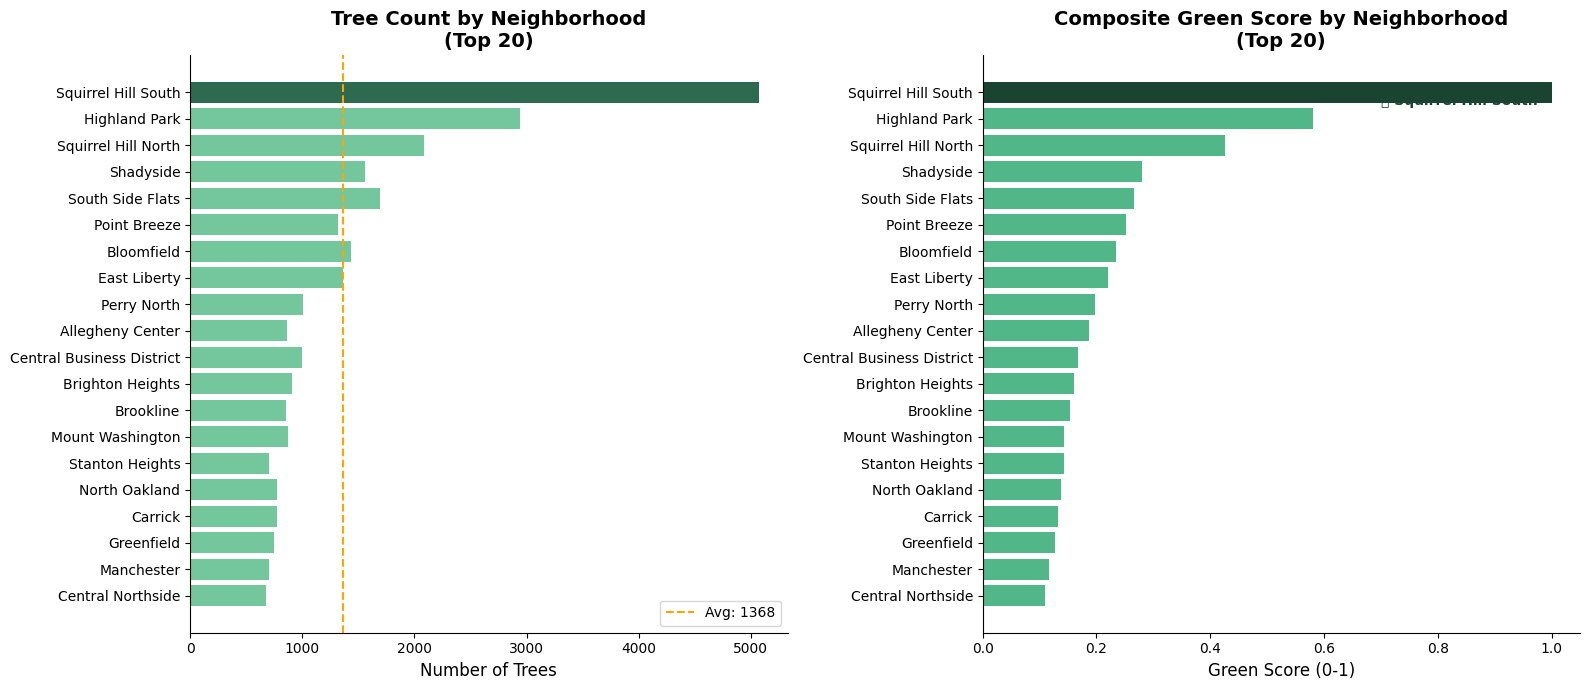


🌳 Greenest neighborhood: Squirrel Hill South (score: 1.000)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Tree count bar chart ---
top20 = green_ranked.head(20)
colors = ['#2d6a4f' if i == 0 else '#74c69d' for i in range(len(top20))]
axes[0].barh(top20['neighborhood'][::-1], top20['tree_count'][::-1], color=colors[::-1])
axes[0].set_xlabel('Number of Trees', fontsize=12)
axes[0].set_title('Tree Count by Neighborhood\n(Top 20)', fontsize=14, fontweight='bold')
axes[0].axvline(x=top20['tree_count'].mean(), color='orange', linestyle='--', 
                label=f'Avg: {top20["tree_count"].mean():.0f}')
axes[0].legend()

# --- Plot 2: Green score bar chart ---
colors2 = ['#1b4332' if i == 0 else '#52b788' for i in range(len(top20))]
axes[1].barh(top20['neighborhood'][::-1], top20['green_score'][::-1], color=colors2[::-1])
axes[1].set_xlabel('Green Score (0-1)', fontsize=12)
axes[1].set_title('Composite Green Score by Neighborhood\n(Top 20)', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1.05)

# Annotate winner
best_name = green_ranked.iloc[0]['neighborhood']
best_score = green_ranked.iloc[0]['green_score']
axes[1].annotate(f'🏆 {best_name}', xy=(best_score, 19), xytext=(best_score - 0.3, 18.5),
                fontsize=10, color='#1b4332', fontweight='bold')

plt.tight_layout()
plt.savefig('green_space_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n🌳 Greenest neighborhood: {best_name} (score: {best_score:.3f})")


### Scatter Plot: Tree Count vs. Environmental Benefit


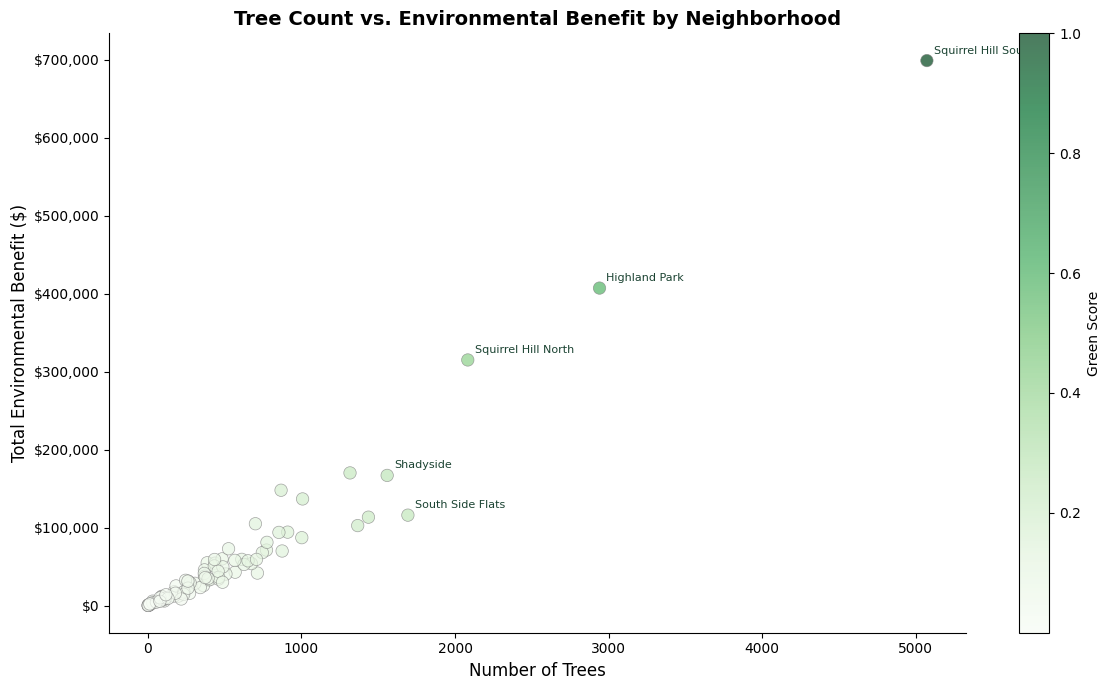

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

# Color by green score
sc = ax.scatter(
    neighborhood_stats['tree_count'],
    neighborhood_stats['total_env_benefit'],
    c=neighborhood_stats['green_score'],
    cmap='Greens',
    s=80,
    alpha=0.7,
    edgecolors='gray',
    linewidth=0.5
)

plt.colorbar(sc, label='Green Score')
ax.set_xlabel('Number of Trees', fontsize=12)
ax.set_ylabel('Total Environmental Benefit ($)', fontsize=12)
ax.set_title('Tree Count vs. Environmental Benefit by Neighborhood', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Label top 5 neighborhoods
top5 = green_ranked.head(5)
for _, row in neighborhood_stats[neighborhood_stats['neighborhood'].isin(top5['neighborhood'])].iterrows():
    ax.annotate(
        row['neighborhood'],
        (row['tree_count'], row['total_env_benefit']),
        textcoords='offset points', xytext=(5, 5),
        fontsize=8, color='#1b4332'
    )

plt.tight_layout()
plt.savefig('green_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusion

Based on my analysis of the **City of Pittsburgh Trees** dataset, **Squirrel Hill South** stands out as Pittsburgh's greenest neighborhood by a significant margin. With over **5,000 city-maintained trees** and a total environmental benefit exceeding **$699,000**, no other Pittsburgh neighborhood comes close — the runner-up has just over half that tree count.

This result makes sense — Squirrel Hill South is one of Pittsburgh's largest and most established residential neighborhoods, with wide, tree-lined streets that reflect decades of urban forestry investment.

**My Green Score Rankings (Top 5):**

| Rank | Neighborhood | Trees | Env. Benefit | Green Score |
|------|-------------|-------|-------------|-------------|
| 1 | Squirrel Hill South | 5,073 | $699,252 | 1.000 |
| 2 | Highland Park | 2,941 | $407,317 | 0.581 |
| 3 | Squirrel Hill North | 2,083 | $315,094 | 0.427 |
| 4 | Shadyside | 1,558 | $166,935 | 0.280 |
| 5 | South Side Flats | 1,693 | $115,953 | 0.266 |

### What this sub-metric brings to the team
From a purely green-space perspective, **Squirrel Hill South** is Pittsburgh's best neighborhood — it's a place where mature tree canopy and urban life coexist, and the data backs it up.

What's interesting for our combined metric: the *scale* of the winner here is extreme (tree count is nearly 2× the #2 neighborhood), so green space will be a very strong signal in the final composite. My safety analysis in `sohan_safety.ipynb` and Pranav's cultural-vibrancy analysis will each add their own flavor. Aayan will then roll all three sub-metrics together in the combined notebook — and we'll see whether Squirrel Hill South's green-space dominance is enough to carry it across the finish line.

---
*Dataset: [City of Pittsburgh Trees](https://data.wprdc.org/dataset/city-trees) — WPRDC*
